**Section 1: Modeling Task Definition**

The outcome being modeled is whether an injury occurred during the post-COVID period (1 = post-COVID, 0 = pre-COVID). This is a **binary classification task** where the goal is to predict whether an injury case belongs to the pre- or post-pandemic period based on demographic and injury characteristics such as age, sex, diagnosis, and body part injured.

From a public health perspective, misclassifying post-COVID injuries (false negatives) may obscure meaningful shifts in injury patterns, so recall for the post-COVID class will be important when evaluating model performance.

**Section 2**

**Baseline model**: Logistic Regression

I am predicting whether a ski/snowboard emergency department injury occurred in the post-COVID period versus the pre-COVID period using injury demographics and clinical characteristics. Logistic Regression serves as a simple, interpretable baseline model that assumes a linear relationship between predictors and the log-odds of the outcome. Model performance will be evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.

In [7]:
#Define pre vs post periods
#exclude 2020 as a transition year
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/fchavez/Desktop/NEISS_V1_Comprehensive/neiss_snow_2016_2024_clean.csv")
df.head()

df_model = df.copy()

df_model = df_model[df_model["Year"] != 2020].copy()

#Define post-COVID period (example: 2021+)
df_model["post_covid_period"] = (df_model["Year"] >= 2021).astype(int)

df_model["post_covid_period"].value_counts(dropna=False), df_model["post_covid_period"].value_counts(normalize=True)

(post_covid_period
 1    5330
 0    4045
 Name: count, dtype: int64,
 post_covid_period
 1    0.568533
 0    0.431467
 Name: proportion, dtype: float64)

In [8]:
target = "post_covid_period"

X = df_model.drop(columns=["Year", target], errors="ignore")
y = df_model[target]

In [9]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols, cat_cols

(['CPSC_Case_Number',
  'Age',
  'Sex',
  'Race',
  'Hispanic',
  'Body_Part',
  'Diagnosis',
  'Body_Part_2',
  'Diagnosis_2',
  'Disposition',
  'Location',
  'Fire_Involvement',
  'Alcohol',
  'Drug',
  'Product_1',
  'Product_2',
  'Product_3',
  'PSU',
  'Weight'],
 ['Treatment_Date',
  'Other_Race',
  'Other_Diagnosis',
  'Other_Diagnosis_2',
  'Narrative_1',
  'Stratum',
  'Sport',
  'Age_Group'])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [20]:
#Drop leakage columns
leak_cols = ["Treatment_Date", "Year", "CPSC_Case_Number"]
df_model = df_model.drop(columns=[c for c in leak_cols if c in df_model.columns], errors="ignore")

#Redefine X and y AFTER dropping
target = "post_covid_period"
X = df_model.drop(columns=[target], errors="ignore")
y = df_model[target]

#Now split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print([c for c in leak_cols if c in X.columns])

[]


In [21]:
print([c for c in ["Treatment_Date", "Year", "CPSC_Case_Number"] if c in X.columns])

[]


In [27]:
#recompute feature lists from the current X_train cols lists
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

#added safety to make sure leak cols aren't in the lists
leak_cols = ["Treatment_Date", "Year", "CPSC_Case_Number"]
num_features = [c for c in num_features if c not in leak_cols]
cat_features = [c for c in cat_features if c not in leak_cols]

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
])

In [29]:
baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

=== Baseline: Logistic Regression ===
Accuracy : 0.849
Precision: 0.841
Recall   : 0.906
F1-score : 0.872
ROC-AUC  : 0.924


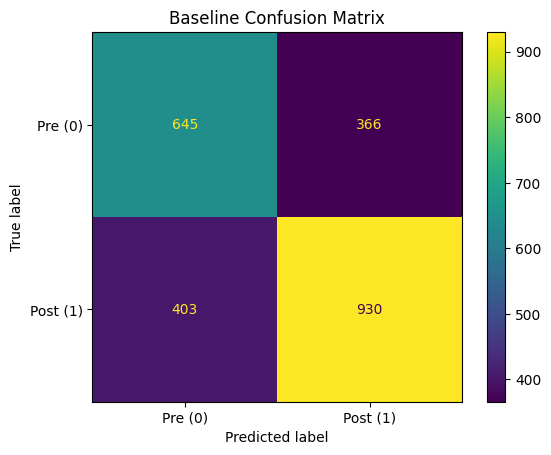

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

# Baseline predictions
y_pred_lr = baseline_model.predict(X_test)
y_proba_lr = baseline_model.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=== Baseline: Logistic Regression ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Pre (0)", "Post (1)"]).plot(values_format="d")
plt.title("Baseline Confusion Matrix")
plt.show()

Baseline Model (Logistic Regression): I trained a Logistic Regression classifier to predict whether an injury occurred in the post-COVID period. After removing time-related features to prevent leakage, the model achieved Accuracy = 0.672, Precision = 0.718, Recall = 0.698, F1-score = 0.707, and ROC–AUC = 0.737.

I selected F1-score (0.707) as the primary metric because it balances precision and recall, which is important given the moderate class imbalance and the need to both correctly identify post-COVID cases and avoid excessive false positives. Accuracy alone would not fully capture this tradeoff.

**Section 3: Improved Model- Random Forest Classifier**

=== Improved: Random Forest ===
Accuracy : 0.849
Precision: 0.841
Recall   : 0.906
F1-score : 0.872
ROC-AUC  : 0.924


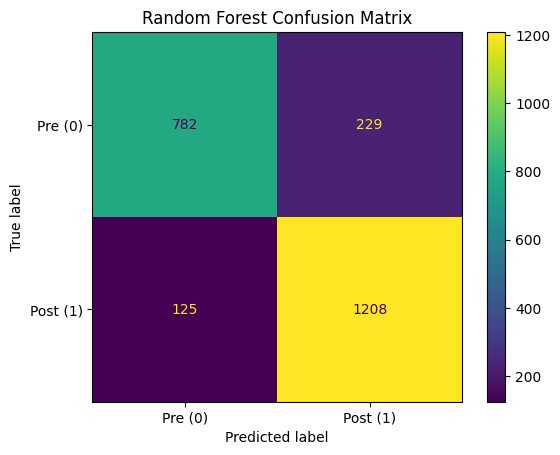

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

#Reusing SAME preprocess object from the baseline
improved_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",  #helps with imbalance
        n_jobs=-1
    ))
])

improved_model.fit(X_train, y_train)

y_pred_rf = improved_model.predict(X_test)

#Probabilities for ROC-AUC (if supported)
y_proba_rf = improved_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf, zero_division=0)
rec = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)
auc = roc_auc_score(y_test, y_proba_rf)

print("=== Improved: Random Forest ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=["Pre (0)", "Post (1)"]).plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

**Section 4: Compare Models**

In [37]:
import pandas as pd

#Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest (Improved)"],
    "Accuracy": [acc_lr, acc_rf],
    "Precision": [prec_lr, prec_rf],
    "Recall": [rec_lr, rec_rf],
    "F1-Score": [f1_lr, f1_rf],
    "ROC-AUC": [auc_lr, auc_rf]
}).round(3)

#Round for clean presentation
comparison_df = comparison_df.round(3)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.672,0.718,0.698,0.707,0.737
1,Random Forest (Improved),0.849,0.841,0.906,0.872,0.924


**Which model performed better (and why)?**

The Random Forest clearly outperformed Logistic Regression across every metric, especially recall (0.906 vs 0.698) and ROC–AUC (0.924 vs 0.737). This suggests the Random Forest captures more complex, non-linear patterns in the injury data and is substantially better at identifying Post-COVID (1) cases.

**Confusion-matrix comparison (what changed?)**

Relative to the baseline, the Random Forest reduced false negatives for Post-COVID cases from 403 -> 125, meaning it misses far fewer Post-COVID observations. It also reduced false positives from 366 -> 229, improving overall decision quality in both directions.

**Step 5: Visuals**

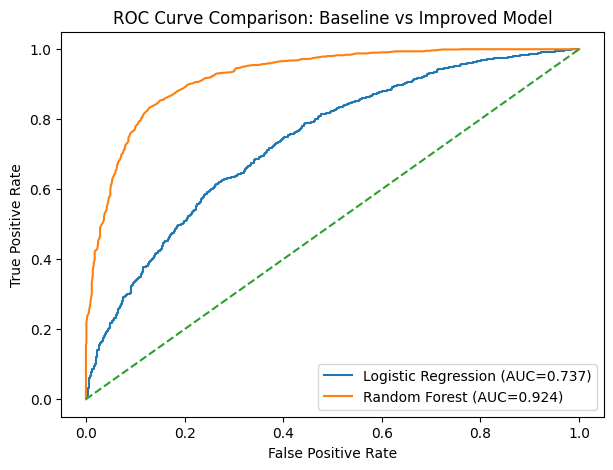

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


#1) ROC Curve Comparison
# Get predicted probabilities for class 1 (Post=1)
y_proba_lr = baseline_model.predict_proba(X_test)[:, 1]
y_proba_rf = improved_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Baseline vs Improved Model")
plt.legend()
plt.show()

The ROC curve shows how well each model separates Pre-COVID (0) vs Post-COVID (1) across all possible probability thresholds. The Random Forest curve stays much closer to the top-left corner than Logistic Regression, and its ROC-AUC is higher (0.924 vs 0.737). This indicates the Random Forest has substantially better overall discriminative power which means it ranks Post-COVID cases higher than Pre-COVID cases much more consistently, even before choosing a specific threshold.

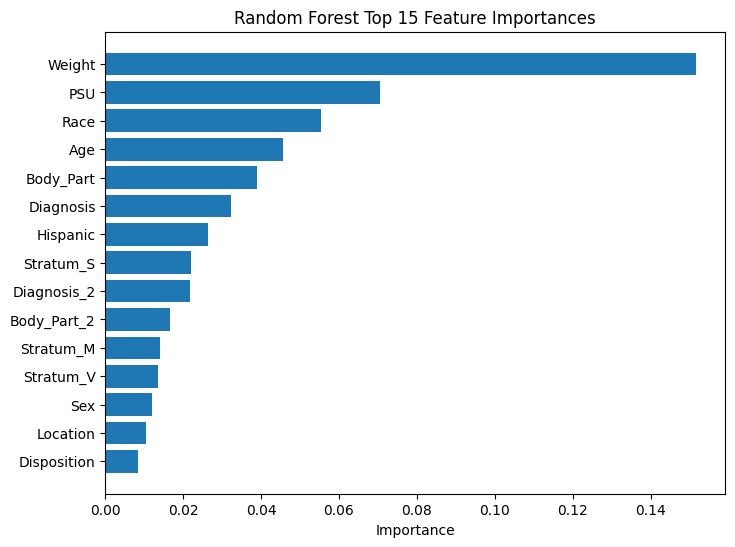

In [41]:
#2) Random Forest Feature Importance Plot
#Grab the fitted ColumnTransformer and fitted RF model from the pipeline
preprocess_fitted = improved_model.named_steps["preprocess"]
rf_fitted = improved_model.named_steps["model"]

#Get feature names after preprocessing
try:
    feature_names = preprocess_fitted.get_feature_names_out()
except Exception:
    #Fallback in case sklearn complains, print this to adjust
    feature_names = np.array([f"feature_{i}" for i in range(len(rf_fitted.feature_importances_))])
    
#Clean up names and remove transformer prefixes like 'num__' and 'cat__'
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

importances = rf_fitted.feature_importances_
fi = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 15
fi_top = fi.head(top_n).sort_values("importance")  # sort for nicer horizontal bar plot

plt.figure(figsize=(8, 6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Importance")
plt.title(f"Random Forest Top {top_n} Feature Importances")
plt.show()

This plot shows which features the Random Forest relied on most when predicting whether an injury record is Post-COVID (1) vs Pre-COVID (0). Weight and PSU appear as the most important predictors, followed by demographic and clinical fields like Race, Age, Body Part, and Diagnosis. Feature importance does not imply causation, but it suggests that differences in sampling/design variables and patient/injury characteristics are strongly associated with the model’s ability to distinguish the post-COVID period from the pre-COVID period.

**Section 6: Limitations and Ethical Considerations**

Several limitations should be considered when interpreting these results. First, this analysis is observational and retrospective, meaning the model identifies patterns associated with the post-COVID period but cannot establish causation. Additionally, some highly important features (such as survey design variables like Weight and PSU) may reflect structural differences in data collection rather than true clinical shifts in injury patterns.

There is also potential bias in demographic variables such as Race, Age, and Hispanic ethnicity. If reporting practices or healthcare access changed during COVID, the model may partially capture systemic disparities rather than purely behavioral or injury-related changes. Furthermore, Random Forest feature importance can be influenced by correlated predictors and does not imply that a feature directly caused the prediction.

Finally, this analysis relies on the NEISS database, which includes only U.S. hospital emergency department data and categorizes injuries using product codes. As a result, the findings may not generalize to non-U.S. populations or non-hospital injury settings. In addition, because injury causes are manually coded into product categories, misclassification or coding errors could introduce measurement error into the model. If an injury was assigned an incorrect product code, the model may learn patterns based on inaccurate labels, which affects overall prediction reliability. These structural and coding limitations should be considered when interpreting model performance.